<a href="https://colab.research.google.com/github/jessicamuetegaleano-ui/Comportamiento-de-los-Clientes---ConnectaTel/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users",users.shape)
print("usage",usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


# inspección de usage con .info()
usage.info()

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())

print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

 **Dataset:Users**
- Se evidencia 469 valores faltantes para la columna `City`el cual corresponde al 11.73% de total de los datos.
- Adicional, se evidencian 3.534 valores nulos para la columna `Churn_date` o "Fecha_de_Baja" los cuales son coherentes debido a que concuerdad con 466 registros de clientes que cancelaron cuadrando los datos para los 4.000 registros por lo cual no presenta ninguna novedad.
    
 **Dataset:Usage**
- Se evidencia 50 datos faltantes para la columna `Date` el cual corresponde al 0.13% del total de los datos.
- Para las columnas `Duration`y `Length`se evidencia un alto porcentaje de valores falatantes sin embargo es coherente con el tipo de servicio (llamadas y mensajes)
- Indica qué harías: ¿imputar, eliminar, ignorar?
- Columna `City`: dejar como nulos.
- columna `Churn_date`: se ignoran dado que tienen coherencia.
- Columna `Date`: Dejar como nulos
- Columnas `Duration` y `Length`: se ignoran dado que tienen coherencia con la columan 'type'

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
#explorar columanas numericas de users
users.describe()


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- la columna `user_id` se evidencia una std alta sin embargo es esperada dado que son numeros secuenciales, su media tambien se encuentra normal.
- la columna `age` el valor minimo de las edades son incorrectas no es posible una edad de -999.      

In [ ]:
#explorar columanas numericas de usage
usage.describe()


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` el valor min y max son coherentes, std alta pero es esperada son secuenciales.
- La columna `duration` tiene algo en particular su valor min es 0 de lo que quizas se pueda deducir una llamada como (no contestada,falla de senal u otros) por lo que seria importante validar el numero de registros en 0 dado que si es de `duration` esta afectando el promedio y la media.
- La columna `length` presenta un caso parecido a `duration` en el min es 0 pero para este caso es algo muy poco comun que un sms se enviado en blanco, se deben validar el No. de registros dado que afentan el promedio.   

In [ ]:
(usage['duration'] == 0).sum()

15

In [ ]:
(usage['length']== 0).sum()

133

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` faltan 565 datos del conteo total de 4.000, las ciudades unicas esperaba mas para ser una data de Lationoamerica.  
- La columna `plan` No evidencio algo inisual los dos planes concuerdan con los de la data plants.

In [ ]:

# explorar columna categórica de usage
usage['type'].value_counts()


text    22092
call    17908
Name: type, dtype: int64

- La columna `type` validando el conteo de las categorias no se evidencia una diferencia en el conteo sin embargo al realizar la comparacion con las columnas numericas del dataset **usage** se evidencia una diferencia en el conteo de las columnas `duration` y `length`


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- **¿En qué columnas encontraste valores inválidos o sentinels?**

    - `age`= -999
    - `duration` y `length`:conteo y valores en 0
    - `city`: ciudades faltantes

- **¿Qué acción tomarías?**
    
- `age`= modificarlos por la media
    - `duration` y `length`_ validar el conteo y los valores en 0 eliminarlos o asignarle una columna.
    - `city`: Colocar los datos como nulos.


## explorar columnas numéricas de usage


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors = 'coerce', utc= True)

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors = 'coerce', utc = True)

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['year']=users['reg_date'].dt.year
users['year'].value_counts()


2024    1330
2023    1316
2022    1314
2026      40
Name: year, dtype: int64

En `reg_date`, tenindo en cuenta que los datos deberian estar registrados hasta 2024, se evidencia 40 datos no coherentes con el año 2026.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['year']=usage['date'].dt.year
usage['year'].value_counts()


2024.0    39950
Name: year, dtype: int64

En `date`, el registro de los años es correcto dado que el registro esta hasta el año 2024, sin embargo hay valores faltantes.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- **¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)**
    - se evidencia años sin transcurrir como 2026.
- **¿Qué harías con ellas?**
    - Colocarlos como valores nulos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age

age_mediana = users['age'].median()
users['age'] =  users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city']= users['city'].replace('?',pd.NA)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024,'reg_date']=pd.NaT

# Verificar cambios
users['reg_date'].describe()


count                                    3960
unique                                   3960
top       2023-12-20 18:33:45.506376600+00:00
freq                                        1
first               2022-01-01 00:00:00+00:00
last                2024-12-31 00:00:00+00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

**Diagnostico**

En `duration` y `length` los valores faltantes son coherentes por naturaleza una llamada no puede tener datos en length y viseversa con el mensaje por lo que tienen logia los valores faltantes y estos se deben mantener.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (usage .groupby('user_id')
    .agg({'is_text':'sum',
          'is_call':'sum',
          'duration':'sum'})
    .reset_index())

# observar resultado
usage_agg.head(3)




,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text':'cant_mensajes','is_call':'cant_llamadas','duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg,on='user_id',how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,2022,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,2022,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,2022,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,2022,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,2022,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,year,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,2023.034000,5.524381,4.478120,23.317054
std,1154.844867,17.690408,0.866044,2.358416,2.144238,18.168095
min,10000.000000,18.000000,2022.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,2022.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,2023.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,2024.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,2026.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

In [ ]:
user_profile['age'].value_counts()

47.0    115
50.0     86
30.0     81
78.0     79
36.0     74
       ... 
57.0     54
51.0     54
62.0     51
68.0     51
70.0     45
Name: age, Length: 62, dtype: int64

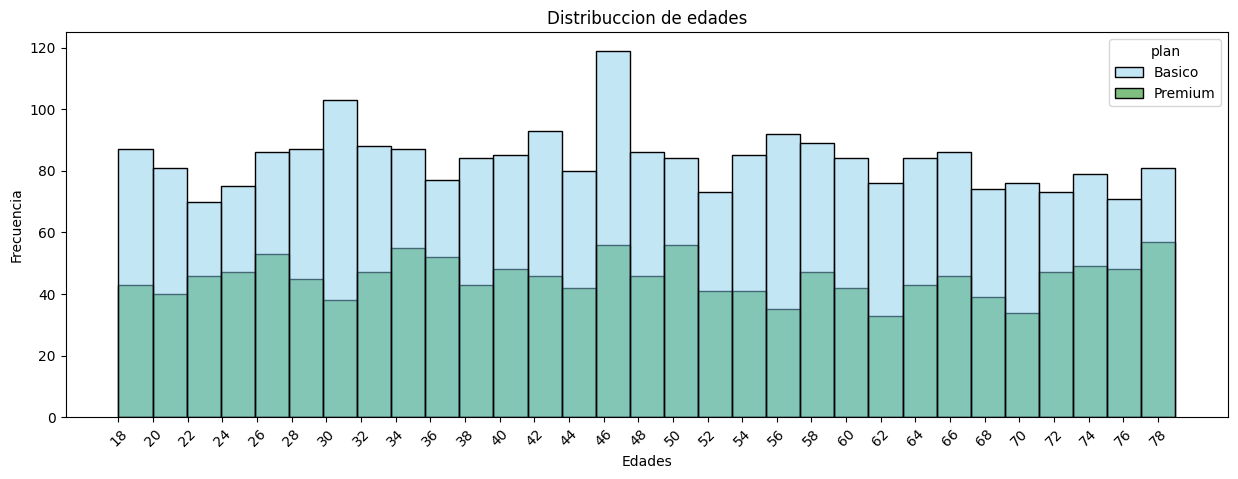

In [ ]:

# Histograma para visualizar la age
plt.figure(figsize=(15,5))
sns.histplot(data=user_profile, x='age', bins=31, hue='plan', palette=['skyblue', 'green'])
plt.xticks(np.arange(18,80,2),rotation=45)

plt.xlabel('Edades')
plt.ylabel('Frecuencia')
plt.title('Distribuccion de edades')

plt.show()



💡Insights:
- Distribución: simetrica
- El plan basico tiene mas usuarios
- No exite ua relacion entre la edad y el plan.
- Se observa una frecuencia mas alta al rededor de los 46-48 años para el plan Basico

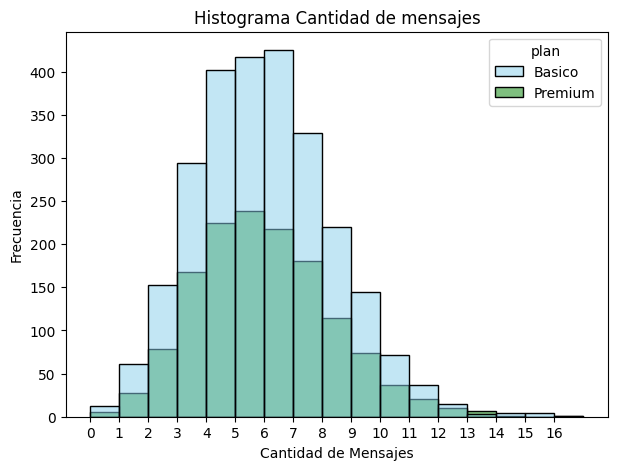

In [ ]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(7,5))
sns.histplot(data=user_profile, x='cant_mensajes', bins=17, hue='plan', palette=['skyblue', 'green'])

plt.xticks(np.arange(0,17,1))

plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.title('Histograma Cantidad de mensajes')

plt.show()



💡Insights:
- La mayoria de los usuarios envia entre 4 y 7 mensajes.
- sesgo a la derecha
- el plan basico presenta mas usurios
- la distribuccion de ambos planes es muy similar

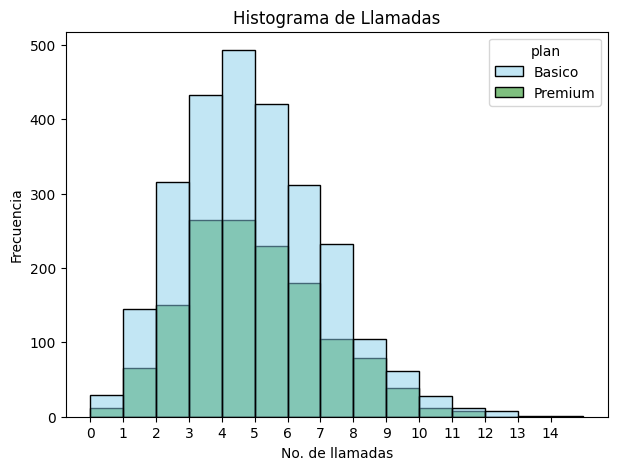

In [ ]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(7,5))
sns.histplot(data=user_profile, x='cant_llamadas', bins=15, hue='plan', palette=['skyblue', 'green'])
plt.xticks(np.arange(0,15,1))


plt.xlabel('No. de llamadas')
plt.ylabel('Frecuencia')
plt.title('Histograma de Llamadas')

plt.show()

💡Insights:
- Distribución:
- Evidencia un frecuencia alta de llamdas entre las 3 a 6 llamadas.
- Evidencia un sesgo a la derecha.
- el plan basico tiene mas usurios.
- Ambos planes tienen una distribuccion muy parecidad.

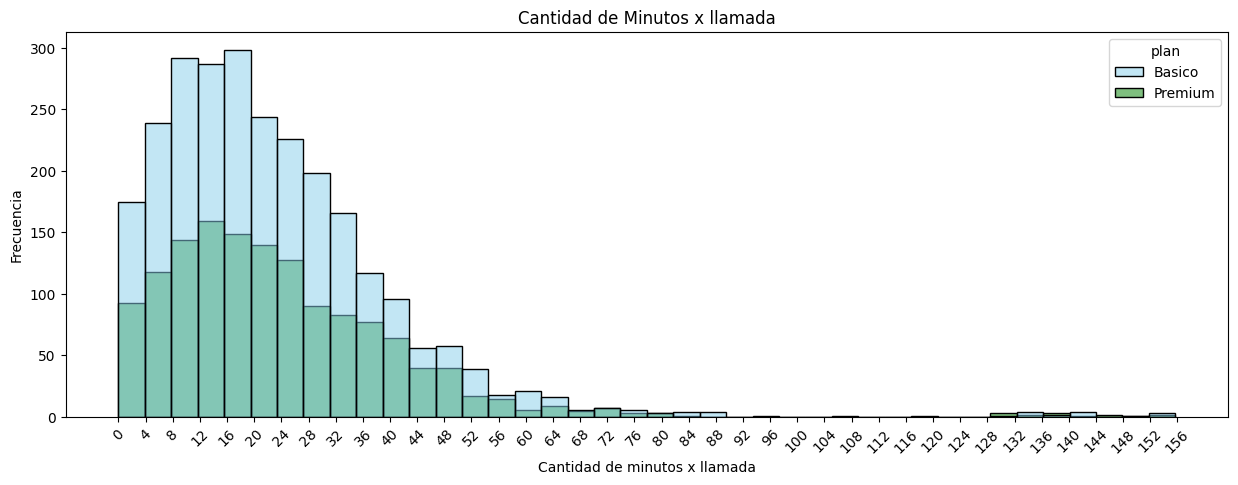

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(15,5))
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=40, hue='plan', palette=['skyblue', 'green'])
plt.xticks(np.arange(0,160,4),rotation=45)

plt.xlabel('Cantidad de minutos x llamada')
plt.ylabel('Frecuencia')
plt.title('Cantidad de Minutos x llamada')

plt.show()

💡Insights:
- Sesgo a la derecha
- Se evidencia > cantidad de minutos x llamada entre 8-20 min para el plan basico
- Se evidencia > cantidad de minutos x llamada entre 8-24 min para el plan Premium.
- se evidencia mas usurios para el plan Basico

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

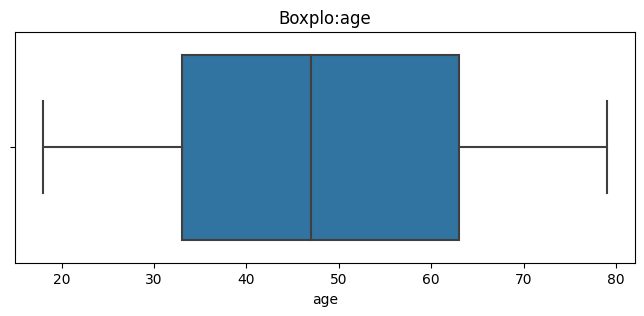

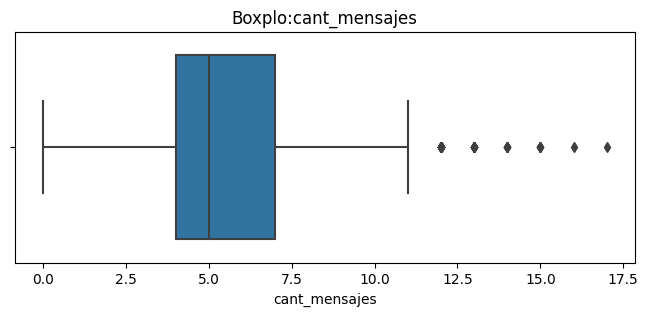

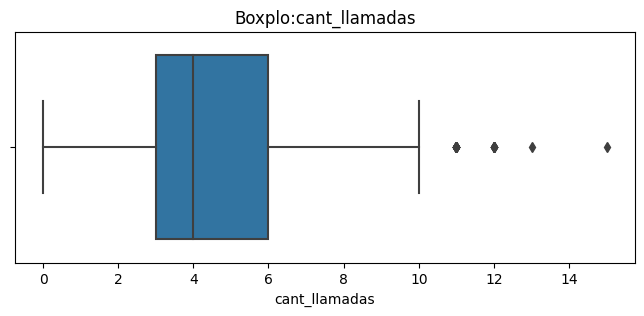

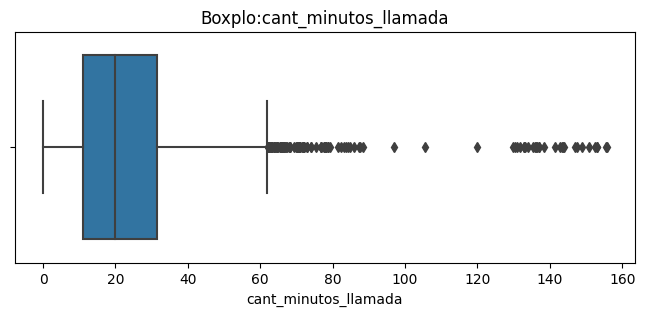

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplo:{col}')
    plt.xlabel(col)
    plt.show()


💡Insights:
- Age: No existen outliers
- cant_mensajes: Exiten outliers
- cant_llamadas: Exiten outliers
- cant_minutos_llamada: Exiten outliers

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']


for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25) # Primer cuartil
    Q3 = user_profile[col].quantile(0.75) # Tercer cuartil
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR


    print(f'\nVariable: {col}')
    print(f'Límite inferior: {limite_inferior:.2f}')
    print(f'Límite superior: {limite_superior:.2f}')



Variable: cant_mensajes
Límite inferior: -0.50
Límite superior: 11.50

Variable: cant_llamadas
Límite inferior: -1.50
Límite superior: 10.50

Variable: cant_minutos_llamada
Límite inferior: -19.32
Límite superior: 61.86


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


In [ ]:
print("Medianas")
print(user_profile[['cant_mensajes','cant_llamadas','cant_minutos_llamada']].median())


Medianas
cant_mensajes            5.00
cant_llamadas            4.00
cant_minutos_llamada    19.78
dtype: float64


Observaciones:
- Distribucciones sesgadas a la derecha
- `Cant_mensajes` y `Cant_llamadas` valores atipicos leves
- `Cant_minutos_llamadas` valores atipicos altos muy por encima del Q3.  

💡Insights:
- **cant_mensajes: mantener o no outliers, porqué?:** Mantener los outliers el valor max que se observa para `Can_mensajes` no excesivamente elevado, la media y la media no tienen mucha diferencia.
- **cant_llamadas: mantener o no outliers, porqué?:** Matener los outliers, el valor max de 15 llamadas no es excesivo es un valor que puede teener un usurio frecuente, la media y la media no presentan mucha diferencia.  
- **cant_minutos_llamada: mantener o no outliers, porqué?:** Matener los outliers ya que un usuario que hable 155 minitos tampoco es tan raro, la  media es considera superior a la media.  

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  

- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.

- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def grupo_uso(fila):
    if fila["cant_llamadas"] < 5 and fila["cant_mensajes"] < 5:
        return "Bajo uso"
    elif fila["cant_llamadas"] < 10 and fila["cant_mensajes"] < 10:
        return "Uso medio"
    else:
        return "Alto uso"

user_profile['grupo_uso'] = user_profile.apply(grupo_uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,2022,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,2022,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,2022,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,2022,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,2022,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:

# Crear columna grupo_edad
def grupo_edad(fila):
    if fila["age"] < 30:
        return "Joven"
    elif fila["age"] < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"

user_profile["grupo_edad"] = user_profile.apply(grupo_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,2022,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,2022,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,2022,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,2022,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,2022,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

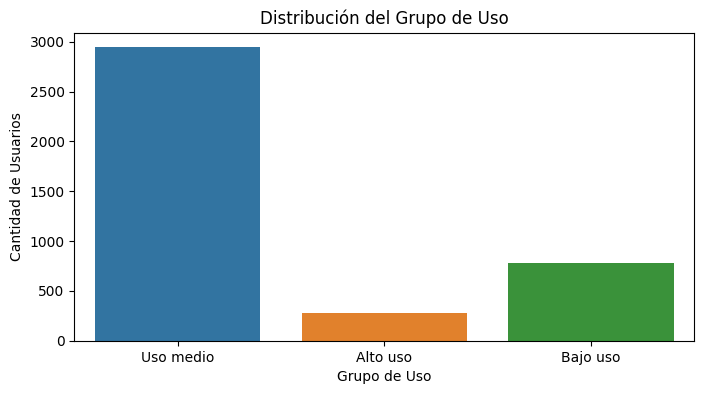

In [ ]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8,4))
sns.countplot(data=user_profile, x="grupo_uso")
plt.title("Distribución del Grupo de Uso")
plt.xlabel("Grupo de Uso")
plt.ylabel("Cantidad de Usuarios")
plt.show()

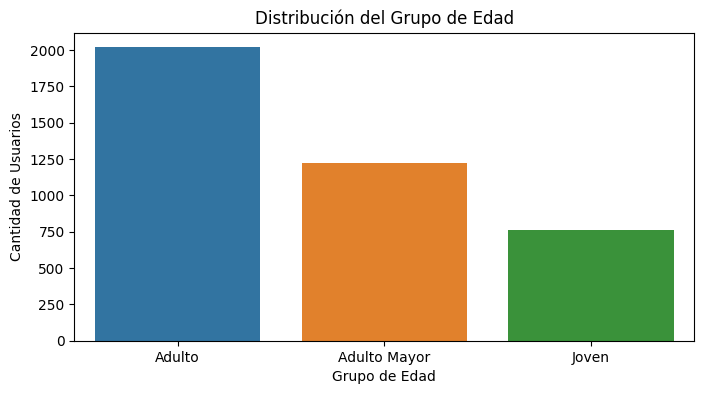

In [ ]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8,4))
sns.countplot(data=user_profile, x="grupo_edad")
plt.title("Distribución del Grupo de Edad")
plt.xlabel("Grupo de Edad")
plt.ylabel("Cantidad de Usuarios")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- Se identificaron valores nulos en los datasets (users y usage)
- Detección de datos incoherentes en columnas categóricas y numéricas.
- Columnas de fechas con tipo de dato erróneo
- Se identifica un año sin transcurrir fuera del rango de fechas del registro.

🔍 **Segmentos por Edad**

- El segmentó por edad que mas predomina es el adulto lo que indica que la base de datos esta compuesta principalmente por personas entre 30y 59 años.
- Los adultos mayores representan el segundo segmento con mayor cantidad de usuarios mientras el de jóvenes el segmento menos representado.

📊 **Segmentos por Nivel de Uso**

- La mayoría de los usuarios presentan comportamientos uso medios un comportamiento moderado
- Los usuarios de bajo uso representan el segundo segmentó más numeroso.
- El grupo de alto uso es el menos representativo

➡️ **Esto sugiere que ...**

- Dado que la mayor proporción de los usuarios se concentra en personas adultas seria una buena oportunidad de comercialización y posterior fidelización.
- La menor participación del segmento Joven representa una oportunidad para diseñar ofertas y nuevas campañas.
- Respecto al uso se evidencia un consumo moderado, sin embargo, sería una oportunidad para identificar las necesidades del segmento de alto uso para aumentar su valor, para el segmento de bajo uso implementar estrategias comerciales.

💡 **Recomendaciones**

- Diseñar e implementar estrategias comerciales especiales para grupos de mayor y de medio uso con el fin de generar mejor fidelización, realizar un seguimiento al los de bajo uso para identificar necesidades.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`